## Cell 1 — Setup & Imports

In [10]:
# @title Cell 1 — Setup & Imports

!pip install wandb -q

import os, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import autograd
from torch.nn.utils import spectral_norm
from torch.utils.data import TensorDataset, DataLoader

from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import LabelEncoder

USE_WANDB = False
print("wandb disabled — console logging only.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()          # AMP only helps on CUDA
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"Device  : {device}")
print(f"AMP     : {USE_AMP}")

print("Cell 1 setup complete.")

wandb disabled — console logging only.
PyTorch : 2.10.0+cpu
CUDA    : False
Device  : cpu
AMP     : False
Cell 1 setup complete.


## Cell 2 — Mount Drive & Paths

In [15]:
# @title Cell 2 — Mount Drive & Paths
# Colab: uses /content/drive/MyDrive/analyticgan (your training layout).
# Local Jupyter/Cursor: skips google.colab; BASE = this repo on disk.

import os

if os.path.exists("/content"):
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    BASE = "/content/drive/MyDrive/analyticgan"
else:
    _cwd = os.path.abspath(os.getcwd())
    if os.path.basename(_cwd) == "notebooks":
        BASE = os.path.dirname(_cwd)
    else:
        BASE = _cwd

CKPT_DIR = os.path.join(BASE, "checkpoints")
DATA_PATH = os.path.join(BASE, "notebooks", "creditcard.csv")
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"BASE      : {BASE}")
print(f"CKPT_DIR  : {CKPT_DIR}")
print(f"DATA_PATH : {DATA_PATH}")

print("Cell 2 configuration complete.")

BASE      : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan
CKPT_DIR  : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints
DATA_PATH : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\notebooks\creditcard.csv
Cell 2 configuration complete.


## Cell 3 — All Class Definitions

In [16]:
# @title Cell 3 — All Class Definitions

class VGMEncoder:
    def __init__(self, n_components=10, eps=0.005):
        self.n_components = n_components
        self.eps          = eps
        self.bgm = BayesianGaussianMixture(
            n_components=n_components,
            weight_concentration_prior_type="dirichlet_process",
            weight_concentration_prior=0.001,
            max_iter=100, random_state=42, n_init=1,
        )
        self.valid_components = None
        self.n_valid          = None

    def fit(self, data):
        data = np.asarray(data).reshape(-1, 1)
        self.bgm.fit(data)
        self.valid_components = np.where(self.bgm.weights_ > self.eps)[0]
        self.n_valid = len(self.valid_components)
        return self

    def transform(self, data):
        data  = np.asarray(data).reshape(-1, 1)
        means = self.bgm.means_[self.valid_components].flatten()
        stds  = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        probs = self.bgm.predict_proba(data)[:, self.valid_components]
        mode_idx = []
        for p in probs:
            s = p.sum()
            p_norm = (p/s).astype(np.float64) if (s > 0 and np.isfinite(s)) \
                     else np.ones(self.n_valid)/self.n_valid
            mode_idx.append(np.random.choice(self.n_valid, p=p_norm))
        mode_idx   = np.array(mode_idx)
        normalized = np.clip(
            (data.flatten() - means[mode_idx]) / (4*stds[mode_idx] + 1e-8),
            -0.99, 0.99)
        one_hot = np.zeros((len(data), self.n_valid), dtype=np.float32)
        one_hot[np.arange(len(data)), mode_idx] = 1
        return np.column_stack([normalized, one_hot]).astype(np.float32)

    def inverse_transform(self, encoded):
        encoded  = np.asarray(encoded)
        means    = self.bgm.means_[self.valid_components].flatten()
        stds     = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        mode_idx = np.argmax(encoded[:, 1:], axis=1)
        return encoded[:, 0] * 4 * stds[mode_idx] + means[mode_idx]


class TabularPreprocessor:
    def __init__(self, max_gmm_components=10, eps=0.005):
        self.max_gmm_components = max_gmm_components
        self.eps             = eps
        self.continuous_cols = []
        self.categorical_cols= []
        self.target_col      = None
        self.vgm_encoders    = {}
        self.label_encoders  = {}
        self.cat_dims        = {}
        self.output_info     = []
        self.output_dim      = 0

    def fit(self, df, continuous_cols, categorical_cols, target_col):
        self.continuous_cols  = continuous_cols
        self.categorical_cols = categorical_cols
        self.target_col       = target_col
        self.output_info = []; self.output_dim = 0
        for col in continuous_cols:
            enc = VGMEncoder(self.max_gmm_components, self.eps)
            enc.fit(df[col].values)
            self.vgm_encoders[col] = enc
            self.output_info.append(("continuous", col, enc.n_valid))
            self.output_dim += 1 + enc.n_valid
        for col in categorical_cols:
            le = LabelEncoder(); le.fit(df[col].astype(str))
            self.label_encoders[col] = le
            n_cat = len(le.classes_)
            self.cat_dims[col] = n_cat
            self.output_info.append(("categorical", col, n_cat))
            self.output_dim += n_cat
        return self

    def transform(self, df):
        parts = []
        for kind, col, _ in self.output_info:
            if kind == "continuous":
                parts.append(self.vgm_encoders[col].transform(df[col].values))
            else:
                lbls  = self.label_encoders[col].transform(df[col].astype(str))
                n_cat = self.cat_dims[col]
                oh    = np.zeros((len(df), n_cat), dtype=np.float32)
                oh[np.arange(len(df)), lbls] = 1
                parts.append(oh)
        data_arr = np.concatenate(parts, axis=1)
        n_cls = df[self.target_col].nunique()
        tgt   = df[self.target_col].values.astype(int)
        cond  = np.zeros((len(df), n_cls), dtype=np.float32)
        cond[np.arange(len(df)), tgt] = 1
        return torch.tensor(data_arr, dtype=torch.float32), cond

    def inverse_transform(self, tensor):
        data, result, idx = tensor.detach().cpu().numpy(), {}, 0
        for kind, col, size in self.output_info:
            if kind == "continuous":
                w = 1 + self.vgm_encoders[col].n_valid
                result[col] = self.vgm_encoders[col].inverse_transform(data[:, idx:idx+w])
                idx += w
            else:
                n_cat = self.cat_dims[col]
                result[col] = self.label_encoders[col].inverse_transform(
                    np.argmax(data[:, idx:idx+n_cat], axis=1))
                idx += n_cat
        return pd.DataFrame(result)

    def save(self, path):
        with open(path, "wb") as f: pickle.dump(self, f)

    @staticmethod
    def load(path):
        with open(path, "rb") as f: return pickle.load(f)


class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
    def forward(self, x): return F.relu(x + self.block(x))


class SelfAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        ad = max(dim // 8, 1)
        self.query    = nn.Linear(dim, ad, bias=False)
        self.key      = nn.Linear(dim, ad, bias=False)
        self.value    = nn.Linear(dim, ad, bias=False)
        self.out_proj = nn.Linear(ad, dim, bias=False)
        self.scale    = ad ** -0.5
    def forward(self, x):
        Q, K, V = self.query(x), self.key(x), self.value(x)
        attn = F.softmax(Q @ K.T * self.scale, dim=-1)
        return x + self.out_proj(attn @ V)


class DiscResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Linear(dim, dim)), nn.LeakyReLU(0.2),
            spectral_norm(nn.Linear(dim, dim)),
        )
    def forward(self, x): return F.leaky_relu(x + self.block(x), 0.2)


class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim, output_dim, output_info, hidden_dims=None):
        super().__init__()
        if hidden_dims is None: hidden_dims = [256, 256]
        self.output_info  = output_info
        self.input_layer  = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]), nn.ReLU(),
        )
        self.res_blocks   = nn.ModuleList([ResidualBlock(d) for d in hidden_dims])
        self.self_attn    = SelfAttention(hidden_dims[-1])
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)

    def forward(self, z, cond):
        x = self.input_layer(torch.cat([z, cond], dim=1))
        for b in self.res_blocks: x = b(x)
        x = self.self_attn(x)
        return self._apply_activations(self.output_layer(x))

    def _apply_activations(self, x):
        out, idx = [], 0
        for kind, _, size in self.output_info:
            if kind == "continuous":
                out.append(torch.tanh(x[:, idx:idx+1]))
                out.append(F.softmax(x[:, idx+1:idx+1+size], dim=1))
                idx += 1 + size
            else:
                out.append(F.softmax(x[:, idx:idx+size], dim=1))
                idx += size
        return torch.cat(out, dim=1)


class Discriminator(nn.Module):
    def __init__(self, input_dim, cond_dim, pac=2, hidden_dims=None):
        super().__init__()
        if hidden_dims is None: hidden_dims = [256, 256]
        self.pac         = pac
        self.input_layer = nn.Sequential(
            spectral_norm(nn.Linear((input_dim + cond_dim)*pac, hidden_dims[0])),
            nn.LeakyReLU(0.2),
        )
        self.res_blocks   = nn.ModuleList([DiscResBlock(d) for d in hidden_dims])
        self.output_layer = spectral_norm(nn.Linear(hidden_dims[-1], 1))

    def forward(self, x, cond):
        inp = torch.cat([x, cond], dim=1)
        inp = inp.view(inp.size(0) // self.pac, -1)
        out = self.input_layer(inp)
        for b in self.res_blocks: out = b(out)
        return self.output_layer(out)


# ── SPEED-UP: GPU-native conditional sampler ─────────────────
class ConditionalSampler:
    """
    All sampling stays on GPU — eliminates numpy↔tensor round-trips
    inside the training loop.
    """
    def __init__(self, preprocessor, cond_vec, device):
        self.prep      = preprocessor
        self.device    = device
        self.n_classes = cond_vec.shape[1]

        counts       = cond_vec.sum(axis=0)
        inv          = 1.0 / (counts + 1e-8)
        self.weights = torch.tensor(inv / inv.sum(), dtype=torch.float32, device=device)

        labels         = np.argmax(cond_vec, axis=1)
        # Store class indices as GPU tensors for O(1) lookup
        self.class_idx = {
            c: torch.tensor(np.where(labels == c)[0], device=device)
            for c in range(self.n_classes)
        }
        # Pre-build one-hot basis on GPU
        self.eye = torch.eye(self.n_classes, device=device)

    def sample_cond(self, n):
        cls  = torch.multinomial(self.weights.expand(n, -1),
                                 num_samples=1).squeeze(1)          # (n,)
        return self.eye[cls]                                        # (n, n_cls)

    def sample_real(self, data_tensor, n):
        cls  = torch.multinomial(self.weights.expand(n, -1),
                                 num_samples=1).squeeze(1)
        cond = self.eye[cls]
        idx  = torch.stack([
            self.class_idx[c.item()][
                torch.randint(len(self.class_idx[c.item()]), (1,), device=self.device)
            ] for c in cls
        ]).squeeze(1)
        return data_tensor[idx], cond


print("All classes loaded.")

print("Cell 3 class definitions complete.")

All classes loaded.
Cell 3 class definitions complete.


## Cell 4 — Load Data & Config

In [17]:
# @title Cell 4 — Load Data & Config

with open(f"{CKPT_DIR}/preprocessor.pkl", "rb") as f:
    prep = pickle.load(f)

data_tensor = torch.load(f"{CKPT_DIR}/data_tensor.pt", map_location="cpu")
cond_vec    = np.load(f"{CKPT_DIR}/cond_vec.npy")

config = {
    "latent_dim"       : 128,
    "generator_dim"    : [256, 256],
    "discriminator_dim": [256, 256],
    "pac"              : 2,
    "lr_g"             : 2e-4,
    "lr_d"             : 2e-4,
    "beta1"            : 0.5,
    "beta2"            : 0.9,
    "n_critic"         : 5,
    "lambda_gp"        : 10,
    "batch_size"       : 500,
    "epochs"           : 30,
    "seed"             : 42,
    "save_every"       : 10,
}

torch.manual_seed(config["seed"])
np.random.seed(config["seed"])

print(f"data_tensor : {data_tensor.shape}")
print(f"cond_vec    : {cond_vec.shape}")
print(f"output_dim  : {prep.output_dim}")

print("Cell 4 data and config loaded.")

data_tensor : torch.Size([284807, 298])
cond_vec    : (284807, 2)
output_dim  : 298
Cell 4 data and config loaded.


## Cell 5 — Instantiate Models & Optimizers

In [18]:
# @title Cell 5 — Instantiate Models & Optimizers

output_dim  = prep.output_dim
output_info = prep.output_info
cond_dim    = cond_vec.shape[1]

G = Generator(
    latent_dim  = config["latent_dim"],
    cond_dim    = cond_dim,
    output_dim  = output_dim,
    output_info = output_info,
    hidden_dims = config["generator_dim"],
).to(device)

D = Discriminator(
    input_dim   = output_dim,
    cond_dim    = cond_dim,
    pac         = config["pac"],
    hidden_dims = config["discriminator_dim"],
).to(device)

# Compile Generator only — D uses create_graph=True in GP which
# is incompatible with torch.compile / aot_autograd
if hasattr(torch, "compile") and torch.cuda.is_available():
    G = torch.compile(G)
    print("torch.compile enabled for Generator only (D skipped — GP incompatibility).")
else:
    print("torch.compile skipped — CPU mode.")

sampler = ConditionalSampler(prep, cond_vec, device)

opt_G = torch.optim.Adam(G.parameters(),
                         lr=config["lr_g"],
                         betas=(config["beta1"], config["beta2"]),
                         fused=torch.cuda.is_available())
opt_D = torch.optim.Adam(D.parameters(),
                         lr=config["lr_d"],
                         betas=(config["beta1"], config["beta2"]),
                         fused=torch.cuda.is_available())

print(f"Generator     params : {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params : {sum(p.numel() for p in D.parameters()):,}")
print("Cell 5 complete.")

torch.compile skipped — CPU mode.
Generator     params : 408,618
Discriminator params : 417,281
Cell 5 complete.


## Cell 6 — Loss Functions

In [19]:
# @title Cell 6 — Loss Functions

def gradient_penalty(D, real, fake, cond, device, lambda_gp=10):
    alpha  = torch.rand(real.size(0), 1, device=device).expand_as(real)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_int  = D(interp, cond)
    grads  = autograd.grad(
        outputs      = d_int,
        inputs       = interp,
        grad_outputs = torch.ones_like(d_int),
        create_graph = True,
        retain_graph = True,
    )[0]
    # SPEED-UP: norm computed in-place, no extra allocation
    gp = lambda_gp * ((grads.norm(2, dim=1) - 1).pow(2)).mean()
    return gp


def compute_d_loss(D, real, fake, cond, device, lambda_gp=10):
    gp     = gradient_penalty(D, real, fake, cond, device, lambda_gp)
    loss_d = D(fake.detach(), cond).mean() - D(real, cond).mean() + gp
    return loss_d, gp


def compute_g_loss(D, fake, cond):
    return -D(fake, cond).mean()


print("Cell 6 loss functions defined.")

Cell 6 loss functions defined.


## Cell 7 — Training Loop

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training: 100 epochs | batch=500 | n_critic=3
LR: D=0.0002  G=0.0001
Device: cuda


W0321 22:16:39.271000 8787 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important u

Epoch   1/100  |  D:-3.7592  G:-2.4721  GP:0.3405  W:4.0997  lr_g:0.000100  [3.6m]
Epoch  10/100  |  D:-1.9405  G:-2.6956  GP:0.1496  W:2.0901  lr_g:0.000098  [10.0m]
Epoch  20/100  |  D:-1.4634  G:-0.6121  GP:0.0947  W:1.5580  lr_g:0.000090  [17.0m]
Epoch  30/100  |  D:-1.2511  G:+0.7252  GP:0.0764  W:1.3275  lr_g:0.000079  [24.1m]
Epoch  40/100  |  D:-1.1426  G:+1.4790  GP:0.0689  W:1.2115  lr_g:0.000065  [31.1m]
Epoch  50/100  |  D:-1.0477  G:+1.9969  GP:0.0627  W:1.1105  lr_g:0.000050  [38.3m]
Epoch  60/100  |  D:-1.0140  G:+2.0918  GP:0.0621  W:1.0761  lr_g:0.000035  [45.4m]
Epoch  70/100  |  D:-0.9990  G:+1.9223  GP:0.0619  W:1.0608  lr_g:0.000021  [52.4m]
Epoch  80/100  |  D:-1.0070  G:+1.8673  GP:0.0623  W:1.0693  lr_g:0.000010  [59.5m]
Epoch  90/100  |  D:-0.9833  G:+1.7831  GP:0.0612  W:1.0444  lr_g:0.000002  [66.4m]
Epoch 100/100  |  D:-0.9774  G:+1.7732  GP:0.0605  W:1.0379  lr_g:0.000000  [73.4m]

Training complete: 100 epochs in 73.4 min
Final W-distance: 1.0379
Best  W-d

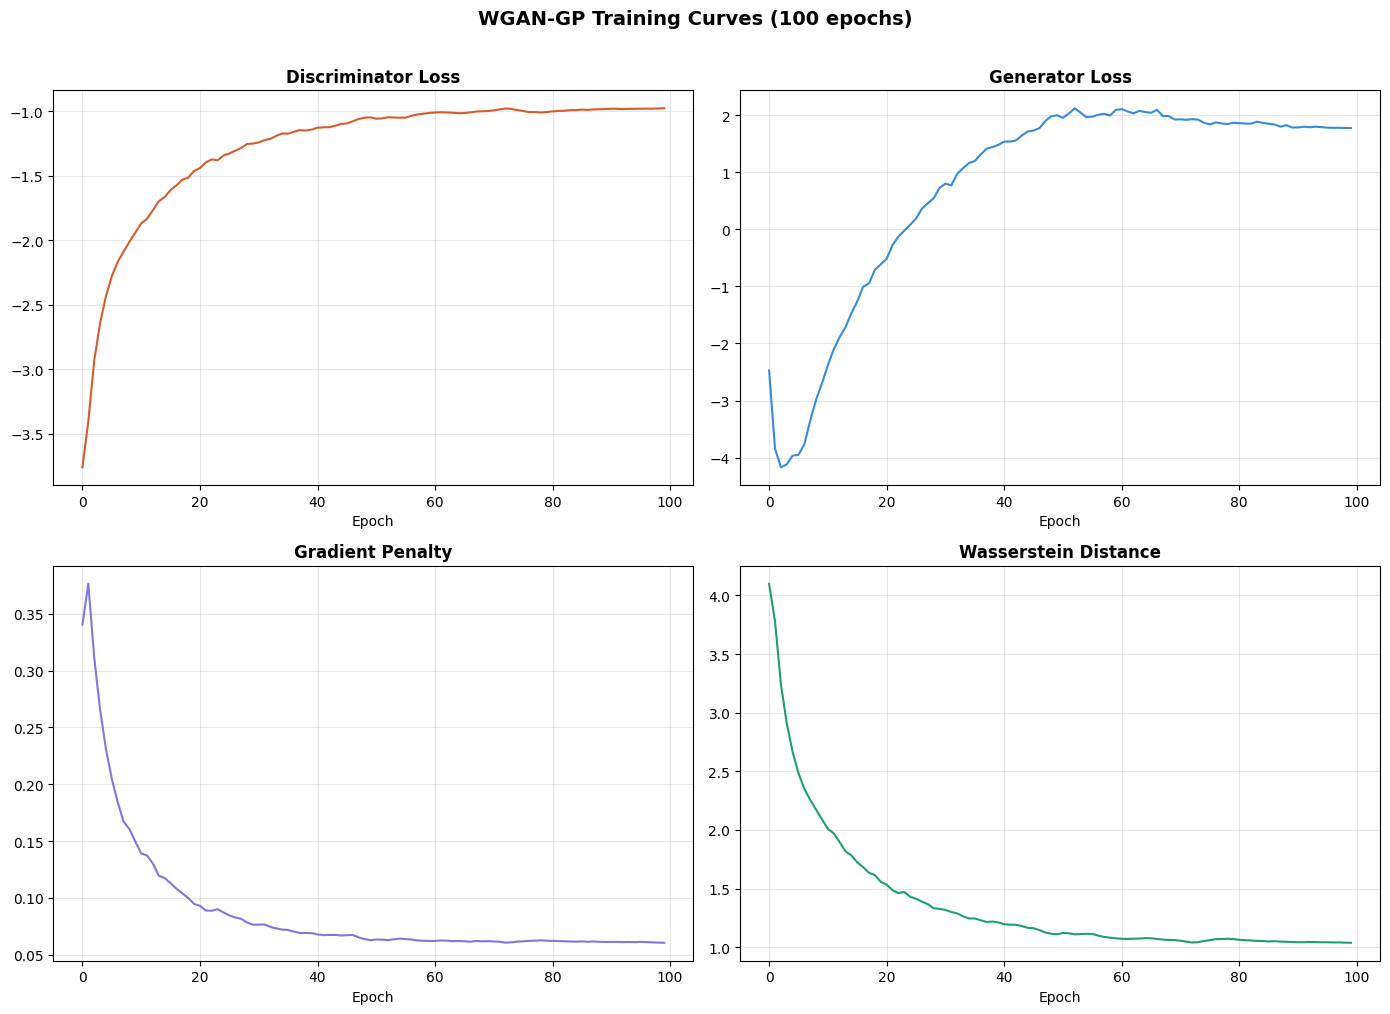

In [ ]:
# ============================================================
# CELL 7 — IMPROVED Training Loop (replace your existing Cell 7)
# ============================================================
# Key changes for better convergence:
#   1. 100 epochs
#   2. Lower G learning rate (1e-4 vs 2e-4) — stops D from overpowering G
#   3. n_critic=3 (was 5) — gives G more updates relative to D
#   4. Cosine LR schedule for both G and D
#   5. NO torch.compile() — avoids _orig_mod. prefix in saved weights
#   6. Save to Google Drive so files persist after disconnect

import time

# ── Checkpoints: Colab Drive OR local <repo>/checkpoints ────
import os
if os.path.exists("/content"):
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    SAVE_DIR = "/content/drive/MyDrive/analyticgan/checkpoints"
else:
    _cwd = os.path.abspath(os.getcwd())
    if os.path.basename(_cwd) == "notebooks":
        _base = os.path.dirname(_cwd)
    else:
        _base = _cwd
    SAVE_DIR = os.path.join(_base, "checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Improved config ─────────────────────────────────────────
config = {
    "latent_dim":  128,
    "hidden_dims": [256, 256],
    "pac":         2,
    "lr_d":        2e-4,       # D learning rate
    "lr_g":        1e-4,       # G learning rate (LOWER — key fix)
    "betas":       (0.5, 0.9),
    "n_critic":    3,          
    "lambda_gp":   10,
    "batch_size":  500,
    "epochs":      100,        
    "save_every":  10,
}

EPOCHS   = config["epochs"]
lat_dim  = config["latent_dim"]
lam      = config["lambda_gp"]
n_critic = config["n_critic"]
bs       = config["batch_size"]

# ── Separate optimizers with different LRs ──────────────────
opt_D = torch.optim.Adam(D.parameters(), lr=config["lr_d"],
                         betas=config["betas"])
opt_G = torch.optim.Adam(G.parameters(), lr=config["lr_g"],
                         betas=config["betas"])

# ── Cosine LR schedulers ────────────────────────────────────
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=EPOCHS)
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=EPOCHS)

# ── Data loader ─────────────────────────────────────────────
dataset = TensorDataset(data_tensor.to(device),
                        torch.tensor(cond_vec, dtype=torch.float32,
                                     device=device))
loader  = DataLoader(dataset, batch_size=bs, shuffle=True, drop_last=True)

history = {"d_loss": [], "g_loss": [], "gp": [], "w_dist": []}

print(f"Training: {EPOCHS} epochs | batch={bs} | n_critic={n_critic}")
print(f"LR: D={config['lr_d']}  G={config['lr_g']}")
print(f"Device: {device}")
print("=" * 65)

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    d_sum, g_sum, gp_sum, steps = 0.0, 0.0, 0.0, 0

    for real_data, real_cond in loader:
        batch_n = real_data.size(0)

        # ── Discriminator steps ─────────────────────────────
        for _ in range(n_critic):
            z         = torch.randn(batch_n, lat_dim, device=device)
            cond_fake = sampler.sample_cond(batch_n)

            with torch.no_grad():
                fake = G(z, cond_fake)

            loss_d, gp = compute_d_loss(D, real_data, fake,
                                        real_cond, device, lam)
            opt_D.zero_grad(set_to_none=True)
            loss_d.backward()
            opt_D.step()

            d_sum  += loss_d.item()
            gp_sum += gp.item()

        # ── Generator step ──────────────────────────────────
        z         = torch.randn(batch_n, lat_dim, device=device)
        cond_fake = sampler.sample_cond(batch_n)
        fake      = G(z, cond_fake)
        loss_g    = compute_g_loss(D, fake, cond_fake)

        opt_G.zero_grad(set_to_none=True)
        loss_g.backward()
        opt_G.step()

        g_sum += loss_g.item()
        steps += 1

    # ── LR schedule step ────────────────────────────────────
    sched_D.step()
    sched_G.step()

    # ── Epoch metrics ───────────────────────────────────────
    avg_d  = d_sum  / (steps * n_critic)
    avg_g  = g_sum  / steps
    avg_gp = gp_sum / (steps * n_critic)
    w_dist = -(avg_d - avg_gp)

    history["d_loss"].append(avg_d)
    history["g_loss"].append(avg_g)
    history["gp"].append(avg_gp)
    history["w_dist"].append(w_dist)

    if epoch % 10 == 0 or epoch == 1:
        elapsed = (time.time() - t0) / 60
        lr_g_now = sched_G.get_last_lr()[0]
        print(f"Epoch {epoch:>3}/{EPOCHS}  |  "
              f"D:{avg_d:+.4f}  G:{avg_g:+.4f}  "
              f"GP:{avg_gp:.4f}  W:{w_dist:.4f}  "
              f"lr_g:{lr_g_now:.6f}  [{elapsed:.1f}m]")

    # Save checkpoints to Drive
    if epoch % config["save_every"] == 0:
        torch.save(G.state_dict(),
                   f"{SAVE_DIR}/generator_ep{epoch}.pt")
        torch.save(D.state_dict(),
                   f"{SAVE_DIR}/discriminator_ep{epoch}.pt")

# ── Final save ──────────────────────────────────────────────
torch.save(G.state_dict(), f"{SAVE_DIR}/generator_final.pt")
torch.save(D.state_dict(), f"{SAVE_DIR}/discriminator_final.pt")

with open(f"{SAVE_DIR}/training_history.pkl", "wb") as f:
    pickle.dump(history, f)

total = (time.time() - t0) / 60
print(f"\n{'='*65}")
print(f"Training complete: {EPOCHS} epochs in {total:.1f} min")
print(f"Final W-distance: {history['w_dist'][-1]:.4f}")
print(f"Best  W-distance: {min(history['w_dist'], key=abs):.4f}")
print(f"Files saved to: {SAVE_DIR}")
print(f"{'='*65}")

# ── Plot training curves ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key, label, color in zip(
    axes.flatten(),
    ["d_loss", "g_loss", "gp", "w_dist"],
    ["Discriminator Loss", "Generator Loss",
     "Gradient Penalty", "Wasserstein Distance"],
    ["#D85A30", "#378ADD", "#7F77DD", "#1D9E75"],
):
    ax.plot(history[key], color=color, linewidth=1.5)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)

plt.suptitle("WGAN-GP Training Curves (100 epochs)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figE_training_curves.png",
            dpi=120, bbox_inches="tight")
plt.show()

## Cell 8 — Training Curves

Loaded 100 epochs


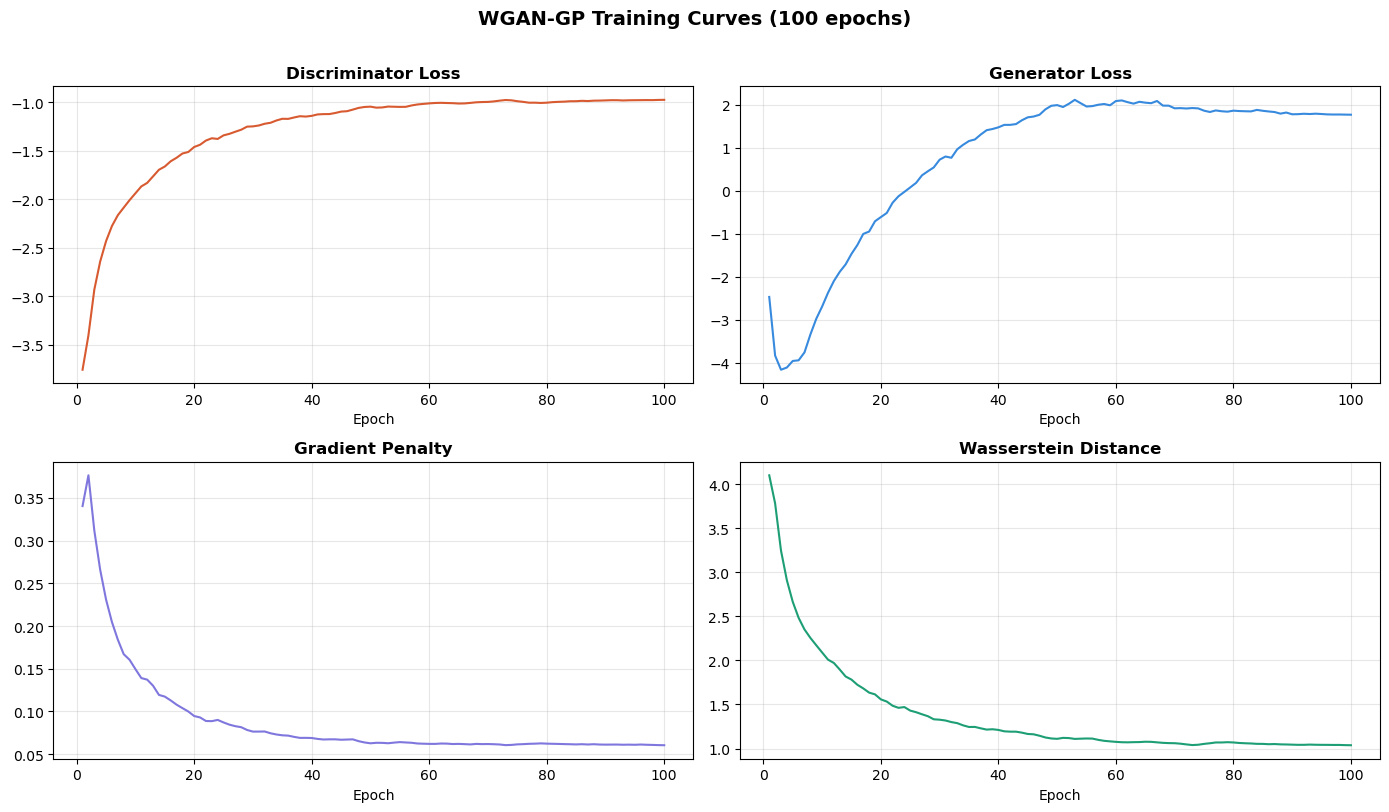

Saved figE_training_curves.png


In [22]:
# @title Cell 8 — Training Curves

import pickle, os
import matplotlib.pyplot as plt

_here = os.path.abspath(os.getcwd())
BASE = _here if os.path.basename(_here) != "notebooks" else os.path.dirname(_here)
CKPT_DIR = os.path.join(BASE, "checkpoints")

with open(os.path.join(CKPT_DIR, "training_history.pkl"), "rb") as f:
    history = pickle.load(f)

print(f"Loaded {len(history['d_loss'])} epochs")

ep_range = range(1, len(history["d_loss"]) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, key, label, color in zip(
    axes,
    ["d_loss", "g_loss", "gp", "w_dist"],
    ["Discriminator Loss", "Generator Loss",
     "Gradient Penalty", "Wasserstein Distance"],
    ["#D85A30", "#378ADD", "#7F77DD", "#1D9E75"],
):
    ax.plot(ep_range, history[key], color=color, linewidth=1.5)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)

plt.suptitle("WGAN-GP Training Curves (100 epochs)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figE_training_curves.png"),
            dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figE_training_curves.png")

## Cell 9 — Generate Synthetic Sample

In [24]:
# @title Cell 9 — Generate Synthetic Sample

from IPython.display import display

lat_dim = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G.eval()
N = 1000

with torch.no_grad():
    z_s    = torch.randn(N, lat_dim, device=device)
    c_s    = sampler.sample_cond(N)
    fake_s = G(z_s, c_s)

df_synthetic          = prep.inverse_transform(fake_s.cpu())
df_synthetic["Class"] = np.argmax(c_s.cpu().numpy(), axis=1)

print(f"Shape  : {df_synthetic.shape}")
print(f"\nClass distribution:")
print(df_synthetic["Class"].value_counts().to_string())
display(df_synthetic.head(10))

print("Cell 9 synthetic sample generated.")

Shape  : (1000, 31)

Class distribution:
Class
1    1000


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,36658.424763,-2.463522,1.036631,-2.949918,-1.115482,-7.773917,0.143849,1.002075,-6.209278,-0.170454,...,1.249658,0.354551,-0.087059,-1.245453,-0.106988,-0.856262,0.092199,0.005013,3.055308,1
1,22664.886451,2.057722,0.910631,-0.982455,-1.334514,-6.422644,0.735688,1.338302,-0.182002,-0.216755,...,-0.012984,0.215174,1.756536,-1.597146,0.367953,-0.485440,-0.473733,-0.373692,15.903724,1
2,19769.178670,0.181655,-1.324678,-2.811777,-1.429436,0.488062,3.942484,-1.961999,-0.365446,-1.157352,...,0.880234,0.026521,2.567987,-0.940655,-0.011306,-0.933837,-1.026358,0.564997,7.095469,1
3,31692.603206,-0.448537,-0.145698,-3.016596,0.743036,0.891688,0.553095,-1.089393,-6.813795,2.409671,...,-0.041880,1.170537,0.001355,-0.101833,0.176658,0.745426,-1.408254,0.057841,4.978767,1
4,61594.363157,2.002176,-2.240234,-1.008724,2.726232,-0.709956,-0.144213,1.312260,-0.061786,-0.407980,...,-0.198112,1.178019,1.558242,-0.105290,0.244226,-0.023501,-0.111847,0.032922,-1.348250,1
5,-2642.102743,-8.517499,-0.734558,-2.918488,-0.671470,0.370293,-0.954301,0.991661,-0.444371,0.992578,...,-0.154538,0.372785,2.214763,-0.386572,0.312410,0.605916,0.389722,-0.191162,24.306278,1
6,25661.617582,-0.866510,-0.971312,-1.428817,-1.419224,-9.120712,0.961866,-0.255442,-4.713129,-0.421443,...,-0.438033,2.076848,0.266410,-1.746718,-0.062430,0.629134,0.729960,0.045974,5.058769,1
7,31762.330091,-8.219119,-2.876605,0.518356,-1.214920,-1.567077,0.453464,0.455039,-0.025415,0.015641,...,0.007204,1.378280,2.499213,-0.071289,-0.662921,0.707906,-0.315115,0.035645,57.284127,1
8,-1815.038493,-0.715351,-0.479711,-3.898939,-1.662808,2.059851,0.733281,-1.926161,-3.777822,1.219297,...,-0.298294,0.636670,4.315983,0.220650,0.409342,1.068571,0.425294,0.079225,-8.131327,1
9,34053.981205,-0.547862,-0.559597,-3.017593,-1.047068,-0.136678,0.428317,-1.953785,-0.409393,0.591849,...,-1.794129,-0.497090,0.006402,-1.231604,0.136862,0.605414,-1.778295,0.000682,0.391983,1


Cell 9 synthetic sample generated.


## Cell 10 — Real vs Synthetic Visual Check

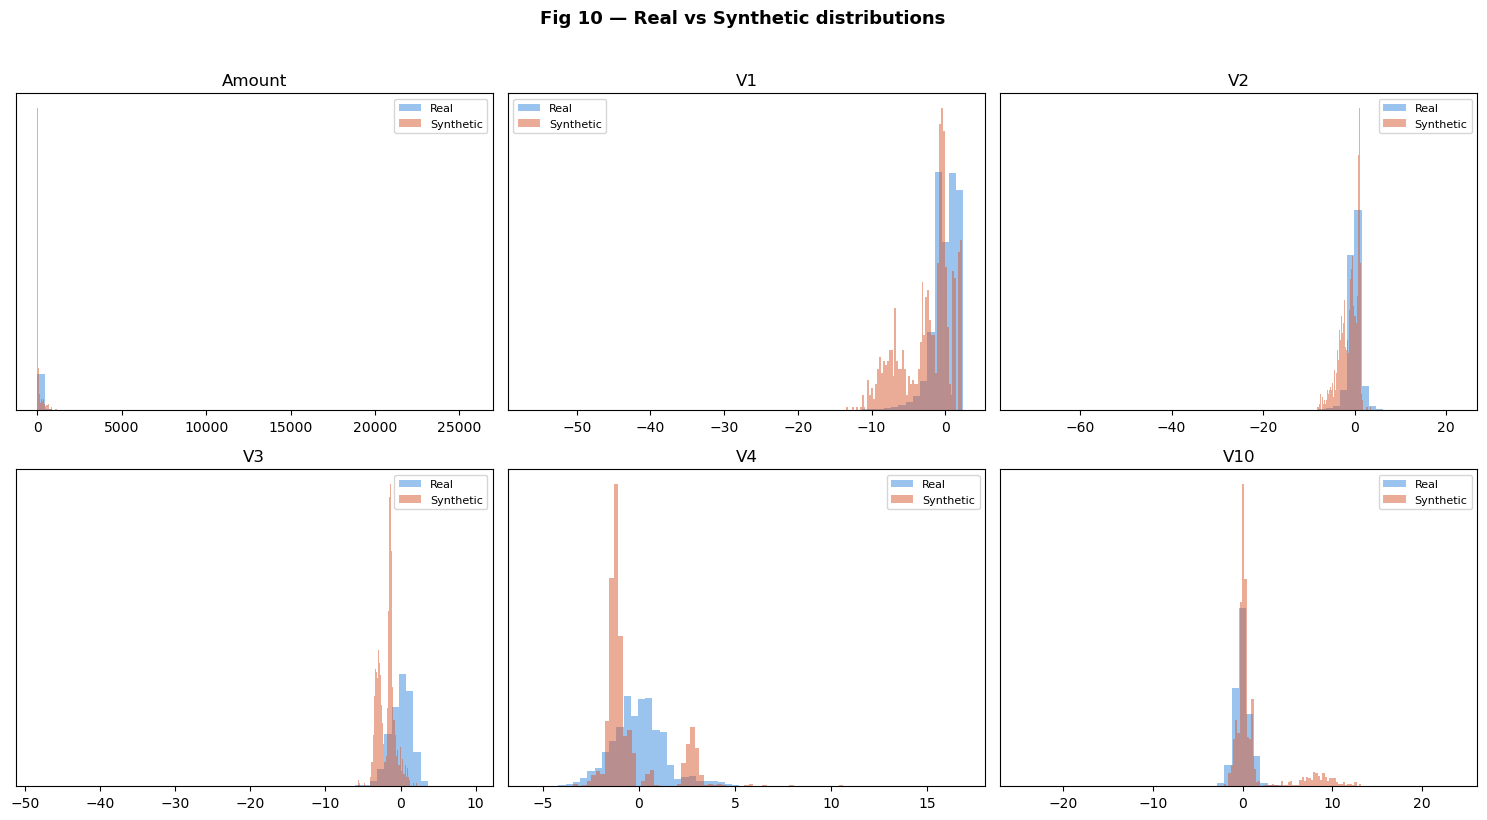

Cell 10 real vs synthetic comparison plotted and saved.


In [25]:
# @title Cell 10 — Real vs Synthetic Visual Check

import kagglehub
_kaggle_path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
RAW_CSV      = os.path.join(_kaggle_path, "creditcard.csv")

df_real    = pd.read_csv(RAW_CSV)
check_cols = ["Amount", "V1", "V2", "V3", "V4", "V10"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes      = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].hist(df_real[col],      bins=60, density=True,
                 color="#378ADD", alpha=0.5, label="Real")
    axes[i].hist(df_synthetic[col], bins=60, density=True,
                 color="#D85A30", alpha=0.5, label="Synthetic")
    axes[i].set_title(col); axes[i].legend(fontsize=8)
    axes[i].set_yticks([])

plt.suptitle("Fig 10 — Real vs Synthetic distributions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/fig10_real_vs_synthetic.png", bbox_inches="tight")
plt.show()

print("Cell 10 real vs synthetic comparison plotted and saved.")

## Cell 11 — Class Balance Check

In [26]:
# @title Cell 11 — Class Balance Check

G.eval()
N_large = 10_000
real_counts = df_real["Class"].value_counts().sort_index()

with torch.no_grad():
    z_l    = torch.randn(N_large, lat_dim, device=device)
    c_l    = sampler.sample_cond(N_large)
    fake_l = G(z_l, c_l)

df_large          = prep.inverse_transform(fake_l.cpu())
df_large["Class"] = np.argmax(c_l.cpu().numpy(), axis=1)

synth_counts = df_large["Class"].value_counts().sort_index()

print("=" * 50)
print("CLASS BALANCE — 10,000 synthetic rows")
print("=" * 50)
for cls in synth_counts.index:
    s_pct = synth_counts[cls] / N_large * 100
    r_pct = real_counts[cls]  / len(df_real) * 100
    print(f"  Class {cls}:  Synthetic={s_pct:.2f}%  |  Real={r_pct:.4f}%")
print("=" * 50)
print("Sampler working if synthetic fraud % >> real fraud %")

print("Cell 11 class balance checked.")

CLASS BALANCE — 10,000 synthetic rows
  Class 0:  Synthetic=0.12%  |  Real=99.8273%
  Class 1:  Synthetic=99.88%  |  Real=0.1727%
Sampler working if synthetic fraud % >> real fraud %
Cell 11 class balance checked.


## Cell 12 — Save All Outputs

In [27]:
# @title Cell 12 — Save All Outputs

with open(f"{CKPT_DIR}/training_history.pkl", "wb") as f:
    pickle.dump(history, f)

df_synthetic.to_csv(f"{CKPT_DIR}/synthetic_sample.csv", index=False)

if USE_WANDB:
    wandb.finish()

print("Saved:")
print(f"  ✓ {CKPT_DIR}/generator_final.pt")
print(f"  ✓ {CKPT_DIR}/discriminator_final.pt")
print(f"  ✓ {CKPT_DIR}/training_history.pkl")
print(f"  ✓ {CKPT_DIR}/synthetic_sample.csv")
print(f"  ✓ {CKPT_DIR}/training_curves.png")
print(f"  ✓ {CKPT_DIR}/fig10_real_vs_synthetic.png")

print("Cell 12 outputs saved.")

Saved:
  ✓ c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints/generator_final.pt
  ✓ c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints/discriminator_final.pt
  ✓ c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints/training_history.pkl
  ✓ c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints/synthetic_sample.csv
  ✓ c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints/training_curves.png
  ✓ c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints/fig10_real_vs_synthetic.png
Cell 12 outputs saved.


## Cell 13 — Training Summary

In [30]:
# @title Cell 13 — Training Summary

best_w = min(history["w_dist"], key=abs)

print("=" * 50)
print("TRAINING SUMMARY")
print("=" * 50)
print(f"  Epochs trained   : {len(history['d_loss'])}")
print(f"  Final D loss     : {history['d_loss'][-1]:+.4f}")
print(f"  Final G loss     : {history['g_loss'][-1]:+.4f}")
print(f"  Final W-distance : {history['w_dist'][-1]:.4f}")
print(f"  Best  W-distance : {best_w:.4f}")
print(f"  Device           : {device}")
print(f"  Checkpoints      : {CKPT_DIR}")
print("=" * 50)
print("\nTraining complete. Proceed to 05_evaluation.ipynb")
print("Cell 13 training summary displayed.")

TRAINING SUMMARY
  Epochs trained   : 100
  Final D loss     : -0.9774
  Final G loss     : +1.7732
  Final W-distance : 1.0379
  Best  W-distance : 1.0379
  Device           : cpu
  Checkpoints      : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints

Training complete. Proceed to 05_evaluation.ipynb
Cell 13 training summary displayed.
